# Part 1: 

In [13]:
from src.model import JiM
from src.train import train_n_steps
from src.denoiser import Denoiser
from src.dataloader import get_dataloader

import src.dataloader as dl

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from pathlib import Path

In [15]:
OUT_DIR = Path("res/part1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Data Visualisation

# v-Prediction Flow Matching at `D = 2`

### Helper Functions

In [16]:
def scatter_plot(data1, data2,
                 title1="Dataset 1", title2="Dataset 2",
                 suptitle=None, save_path=None, show=True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, data, title in [(axes[0], data1, title1), (axes[1], data2, title2)]:
        ax.scatter(data[:, 0], data[:, 1], alpha=0.5, s=10)
        ax.set_title(title)
        ax.set_xlabel("Dimension 1")
        ax.set_ylabel("Dimension 2")
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)

    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"saved -> {save_path}")
    if show:
        plt.show()
    plt.close(fig)

saved -> res/part1/swiss_roll_visual.png


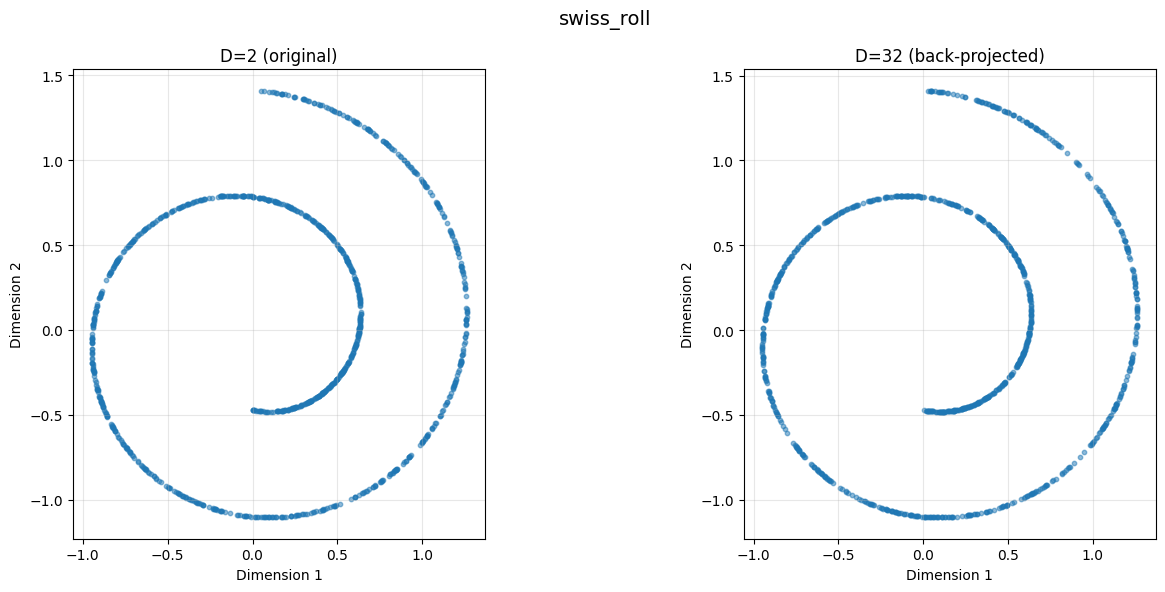

saved -> res/part1/gaussians_visual.png


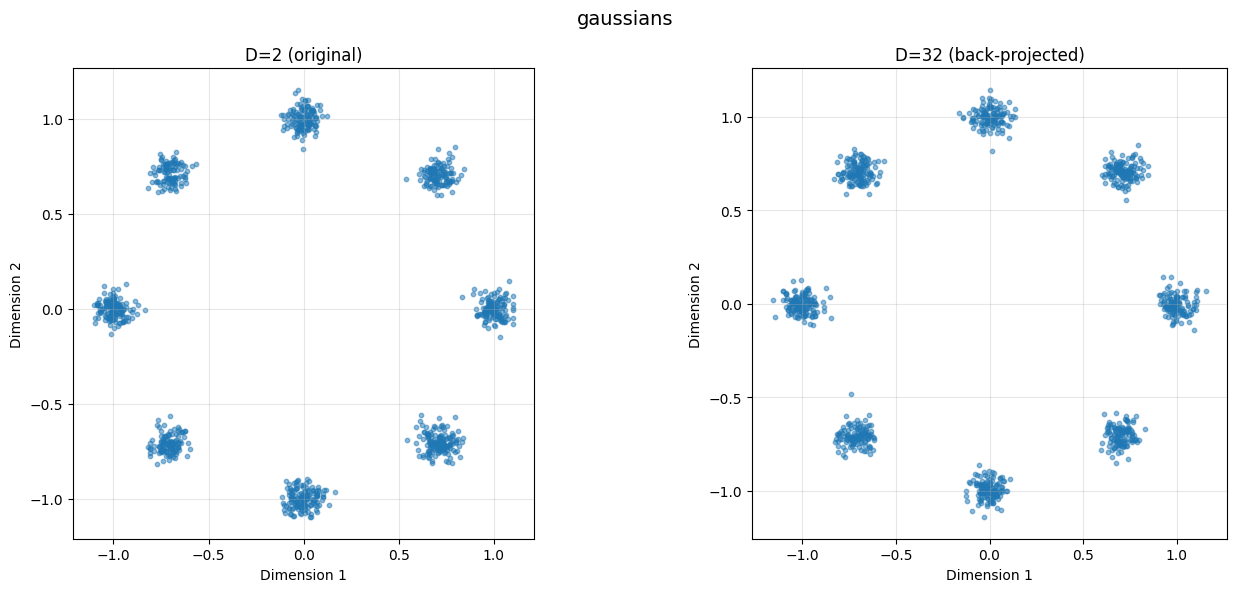

saved -> res/part1/circles_visual.png


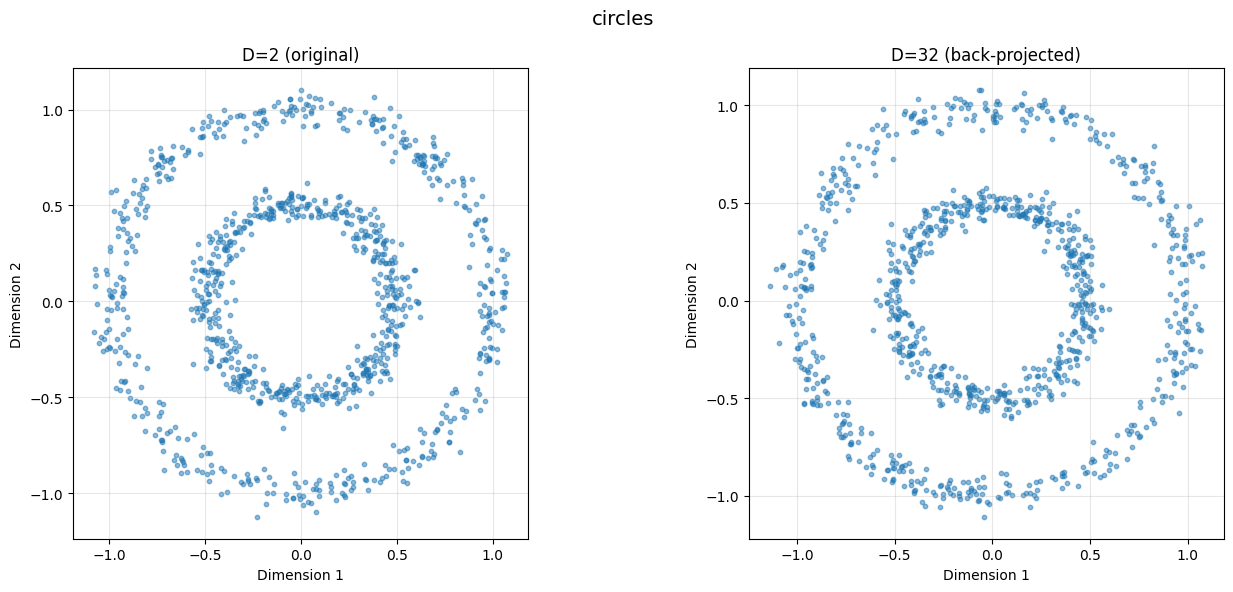

In [18]:
sz = [2, 32]
for dataset in dl.AVAILABLE_DATASETS:
    image_low = next(iter(dl.get_dataloader(name=dataset, dim=sz[0])))
    image_high = next(iter(dl.get_dataloader(name=dataset, dim=sz[1])))
    image_high_2d = dl.ToyDiffusionDataset(dataset, dim=sz[1]).to_2d(image_high)

    scatter_plot(
        image_low, image_high_2d,
        title1=f"D={sz[0]} (original)",
        title2=f"D={sz[1]} (back-projected)",
        suptitle=f"{dataset}",
        save_path=OUT_DIR / f"{dataset}_visual.png",
    )

### Helper Functions

In [7]:
N_GEN = 2048

In [22]:
def scatter_plot(generated, truth=None, title="Scatter Plot",
                 save_path=None, show=True):
    fig = plt.figure(figsize=(8, 6))
    if truth is not None:
        plt.scatter(truth[:, 0], truth[:, 1],
                    alpha=0.3, s=10, c="gray", label="ground truth")
    plt.scatter(generated[:, 0], generated[:, 1],
                alpha=0.6, s=10, c="C0", label="generated")
    plt.title(title)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.gca().set_aspect("equal")
    plt.legend(loc="upper right", framealpha=0.9)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"saved -> {save_path}")
    if show:
        plt.show()
    plt.close(fig)

In [23]:
device = torch.device('cuda')

step    500/25000  loss 1.079655
step   1000/25000  loss 1.006881
step   1500/25000  loss 0.990785
step   2000/25000  loss 0.972078
step   2500/25000  loss 0.963998
step   3000/25000  loss 0.963398
step   3500/25000  loss 0.958598
step   4000/25000  loss 0.958021
step   4500/25000  loss 0.955399
step   5000/25000  loss 0.956598
step   5500/25000  loss 0.955964
step   6000/25000  loss 0.954190
step   6500/25000  loss 0.955381
step   7000/25000  loss 0.954474
step   7500/25000  loss 0.951200
step   8000/25000  loss 0.951563
step   8500/25000  loss 0.949113
step   9000/25000  loss 0.949239
step   9500/25000  loss 0.951989
step  10000/25000  loss 0.952164
step  10500/25000  loss 0.953050
step  11000/25000  loss 0.952523
step  11500/25000  loss 0.950027
step  12000/25000  loss 0.949821
step  12500/25000  loss 0.948487
step  13000/25000  loss 0.948233
step  13500/25000  loss 0.946039
step  14000/25000  loss 0.949324
step  14500/25000  loss 0.944364
step  15000/25000  loss 0.950989
step  1550

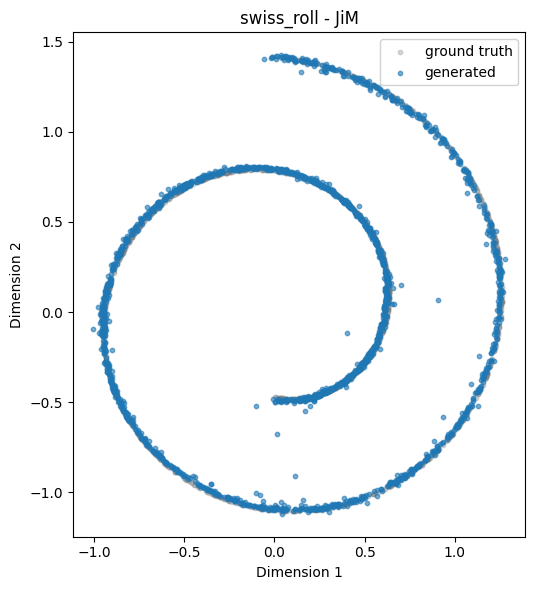

step    500/25000  loss 1.051495
step   1000/25000  loss 0.938939
step   1500/25000  loss 0.925734
step   2000/25000  loss 0.923004
step   2500/25000  loss 0.916360
step   3000/25000  loss 0.918074
step   3500/25000  loss 0.918402
step   4000/25000  loss 0.914660
step   4500/25000  loss 0.914925
step   5000/25000  loss 0.914743
step   5500/25000  loss 0.915175
step   6000/25000  loss 0.912542
step   6500/25000  loss 0.914353
step   7000/25000  loss 0.912159
step   7500/25000  loss 0.912291
step   8000/25000  loss 0.913586
step   8500/25000  loss 0.911104
step   9000/25000  loss 0.909844
step   9500/25000  loss 0.913149
step  10000/25000  loss 0.909384
step  10500/25000  loss 0.910472
step  11000/25000  loss 0.910292
step  11500/25000  loss 0.909235
step  12000/25000  loss 0.906928
step  12500/25000  loss 0.905582
step  13000/25000  loss 0.905735
step  13500/25000  loss 0.906880
step  14000/25000  loss 0.909466
step  14500/25000  loss 0.904669
step  15000/25000  loss 0.907043
step  1550

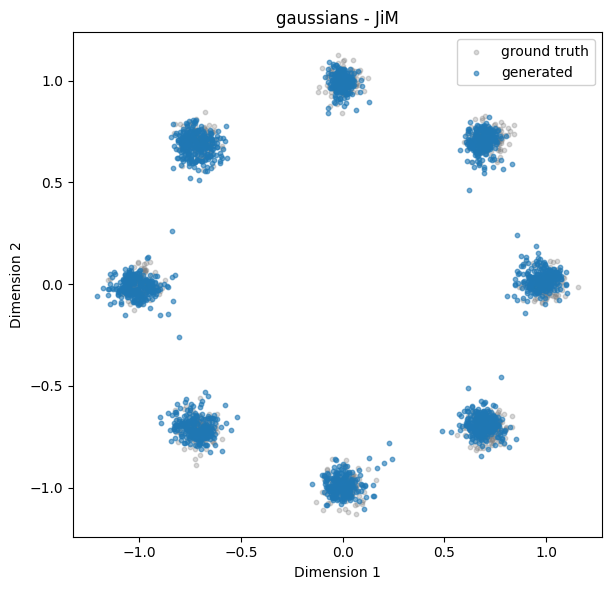

step    500/25000  loss 0.923171
step   1000/25000  loss 0.867326
step   1500/25000  loss 0.870719
step   2000/25000  loss 0.864563
step   2500/25000  loss 0.862826
step   3000/25000  loss 0.852169
step   3500/25000  loss 0.851139
step   4000/25000  loss 0.845953
step   4500/25000  loss 0.844426
step   5000/25000  loss 0.846431
step   5500/25000  loss 0.842342
step   6000/25000  loss 0.842644
step   6500/25000  loss 0.841125
step   7000/25000  loss 0.843964
step   7500/25000  loss 0.840394
step   8000/25000  loss 0.838256
step   8500/25000  loss 0.842714
step   9000/25000  loss 0.842761
step   9500/25000  loss 0.840694
step  10000/25000  loss 0.839874
step  10500/25000  loss 0.838380
step  11000/25000  loss 0.840089
step  11500/25000  loss 0.839156
step  12000/25000  loss 0.840207
step  12500/25000  loss 0.839606
step  13000/25000  loss 0.837635
step  13500/25000  loss 0.837704
step  14000/25000  loss 0.840158
step  14500/25000  loss 0.839911
step  15000/25000  loss 0.841220
step  1550

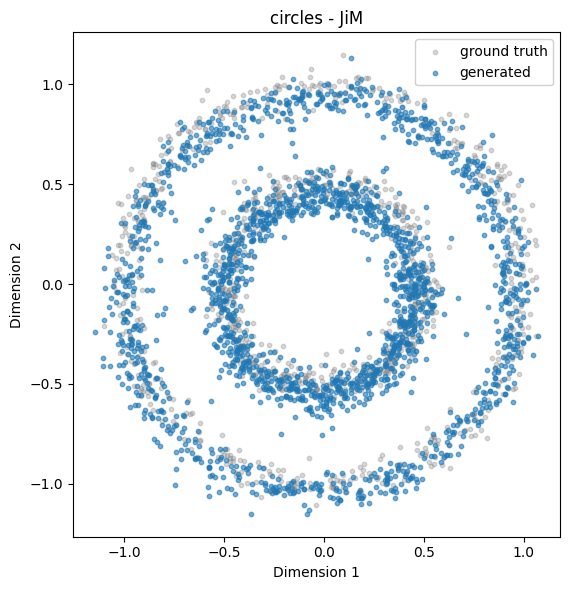

In [24]:
for dataset in dl.AVAILABLE_DATASETS:

    # Dataloader
    dataloader = get_dataloader(name=dataset, dim=2, batch_size=1024)
    # MLP Model
    model = JiM(hidden_dim=256, D=2)
    model = model.to(device)
    # Optimiser
    opt = optim.Adam(model.parameters(), lr=1e-3)
    # Train Steps
    train_steps = 25000
    # Denoising steps
    steps = 50

    # Train
    loss = train_n_steps(model, dataloader, opt, device, train_steps, 'v', 'v',)

    # Generate
    denoiser = Denoiser(model, steps=steps, D=2)
    out = denoiser.generate(N_GEN, 'v', device)
    truth = next(iter(dataloader))[:N_GEN].cpu().numpy()

    scatter_plot(out.cpu(), truth, title=f"{dataset} - JiM" , save_path=OUT_DIR / f"{dataset}_JiM.png",)